# Tutorial 3 — Virtual Screening with AutoDock Vina
**Author:** Himanshu Goel | [Website](https://himanshugoel.github.io)

## Overview
Virtual screening uses computational docking to predict how drug-like molecules bind to protein targets. In this tutorial, we screen compounds against the **Dopamine D2 receptor (DRD2)** — a key neurological target for treating schizophrenia, Parkinson's disease, and addiction.

**AutoDock Vina** is a widely used docking engine in drug discovery. This tutorial demonstrates:
- ✅ Preparing ligands and the receptor for docking
- ✅ Running docking calculations with Vina
- ✅ Validating compound structures
- ✅ Analyzing and visualizing binding predictions

### About Real vs. Estimated Docking
- **Real docking** with AutoDock Vina: uses physics-based scoring and requires receptor/ligand preparation
  - Install: `brew install autodock-vina` or `conda install -c conda-forge vina`
  - Can also use `pip install vina` if your system has the required C++ build dependencies
- **Estimated docking** (fallback): uses molecular properties when Vina is unavailable
  - Works without additional dependencies
  - Good for learning and initial filtering

In [ ]:
# ============================================================================
# Setup: Install Required Python Packages
# ============================================================================
# These are the Python package dependencies needed for this tutorial.
# AutoDock Vina itself is a separate binary or Python wrapper.

!pip install rdkit numpy pandas matplotlib -q

print("✅ Python packages installed successfully")
print()
print("Optional: Install AutoDock Vina for real docking:")
print("  macOS:  brew install autodock-vina")
print("  Linux:  conda install -c conda-forge vina")
print("  Python wrapper: pip install vina  # may require boost/Open Babel on your system")
print()
print("If Vina is not available, this notebook will fall back to estimated scores based on molecular properties.")

## 1. Understanding the target (DRD2 - Dopamine D2 Receptor)

## Background: Why DRD2?
**DRD2 (Dopamine D2 Receptor)** is a G-protein coupled receptor (GPCR) in the brain involved in dopamine signaling. It's a major pharmaceutical target because:
- Antipsychotic drugs (haloperidol, risperidone, aripiprazole) all bind DRD2
- Key role in schizophrenia, bipolar disorder, and OCD
- Well-characterized with many crystal structures available
- Excellent model for learning virtual screening workflows

In [ ]:
# ============================================================================
# SECTION 1: Understanding the Target (DRD2 - Dopamine D2 Receptor)
# ============================================================================
# AutoDock Vina docks ligands against a prepared receptor file in PDBQT format.

import os

print("Using DRD2 (Dopamine D2 receptor) as our demonstration target")
print()

print("DRD2 (Dopamine D2 Receptor):")
print("- G-protein coupled receptor (GPCR) in the brain")
print("- Key target for antipsychotic medications (haloperidol, risperidone)")
print("- Involved in schizophrenia, Parkinson's disease, and addiction")
print("- Well-studied with many known ligands and crystal structures")
print("- For Vina, we need a prepared receptor PDBQT file")
print()

receptor_pdbqt = 'drd2_receptor.pdbqt'
print(f'Receptor file expected at: {receptor_pdbqt}')

if os.path.exists(receptor_pdbqt):
    print('✅ Receptor file found. Vina docking can proceed.')
else:
    print('⚠️  Receptor file not found.')
    print('   To run real Vina docking, download a DRD2 structure and prepare it as PDBQT.')
    print('   You can use AutoDockTools, Open Babel, or other protein preparation tools.')
    print('   Example receptor filename: drd2_receptor.pdbqt')

print()
print('If you do not have a prepared receptor file, this notebook will still show the Vina workflow and fallback scoring.')

Using DRD2 (Dopamine D2 receptor) as our demonstration target

DRD2 (Dopamine D2 Receptor):
- G-protein coupled receptor (GPCR) in the brain
- Key target for antipsychotic medications (haloperidol, risperidone)
- Involved in schizophrenia, Parkinson's disease, and addiction
- Well-studied with many known ligands and crystal structures
- Dockstring has this target pre-configured and ready to use!

Checking available Dockstring targets...
(Note: API may vary - this tries multiple methods)

Could not find target listing method, trying common targets...
Found 6 working targets by testing

Available targets (6 found):
  ABL1    CDK2    DRD2    EGFR    JAK2  
  SRC  


## 2. Define ligands (SMILES format)

In [ ]:
# ============================================================================
# SECTION 2: Define Ligands (SMILES Format)
# ============================================================================
# We prepare ligands from SMILES and later convert them for Vina docking.
# SMILES (Simplified Molecular Input Line Entry System) represents molecules as text

# Dictionary of compounds to test: name -> SMILES string
# These are diverse compounds including antivirals, natural products, and known drugs
# We'll test them against DRD2 to see their relative binding affinities
compounds = {
    "Nirmatrelvir": "CC1(C2CC2CN1C(=O)[C@@H](NC(=O)[C@@H]3CCCN3C(=O)C(C)(C)F)C(C)(C)C)F",  # Paxlovid active ingredient
    "GC376":        "CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H]1CC(=O)N2CCC[C@H]12",     # Broad-spectrum antiviral
    "Ebselen":      "O=C1OC(=Nc2ccccc2[Se]1)c1ccccc1",                                       # Organoselenium compound
    "Baicalein":    "O=c1cc(-c2ccccc2)oc2cc(O)c(O)c(O)c12",                                  # Natural flavonoid
    "Quercetin":    "O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12",                            # Natural flavonoid
}

# Validate SMILES strings using RDKit
from rdkit import Chem

print("Validating SMILES strings...")
for name, smiles in compounds.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"❌ {name}: Invalid SMILES")
    else:
        print(f"✅ {name}: Valid SMILES ({mol.GetNumAtoms()} atoms, {mol.GetNumBonds()} bonds)")

print(f"\nReady to dock {len(compounds)} compounds against DRD2 (Dopamine D2 receptor)")

Validating SMILES strings...
✅ Nirmatrelvir: Valid SMILES (29 atoms, 31 bonds)
✅ GC376: Valid SMILES (28 atoms, 30 bonds)
✅ Ebselen: Valid SMILES (18 atoms, 20 bonds)
✅ Baicalein: Valid SMILES (20 atoms, 22 bonds)
✅ Quercetin: Valid SMILES (22 atoms, 24 bonds)

Ready to dock 5 compounds against DRD2 (Dopamine D2 receptor)


## Note on Docking Methods

### Real Docking with AutoDock Vina
AutoDock Vina requires:
- a prepared receptor file (`.pdbqt`)
- prepared ligand files (`.pdbqt`) or a ligand conversion workflow
- a defined search box around the active site

This notebook shows how to set up a Vina workflow and run docking when the binary or wrapper is available.

### Estimated Scoring (Fallback)
If Vina or receptor preparation tools are unavailable, this notebook uses **molecular property-based scoring**:
- **Molecular weight**: Optimal range 300-500 Da (Lipinski's rule)
- **LogP**: Lipophilicity range 1-3 (ADME favorable)
- **TPSA**: Topological polar surface area <60 for CNS penetration (important for DRD2)
- **H-bond donors/acceptors**: Fewer is generally better for binding

This heuristic works reasonably for initial screening but is less accurate than real docking.

## 3. Run docking with AutoDock Vina

In [ ]:
# This notebook uses AutoDock Vina for docking.
# Receptor preparation and docking are handled in the Vina workflow below.
# The target is DRD2 (Dopamine D2 receptor).

pass

Using DRD2 (Dopamine D2 receptor) as our demonstration target
DRD2 is a GPCR involved in neurological disorders and antipsychotic drugs

✅ Successfully loaded DRD2 target


In [ ]:
# ============================================================================
# SECTION 3: Perform Docking with AutoDock Vina
# ============================================================================
import os
import shutil
import subprocess
import tempfile
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen

receptor_pdbqt = 'drd2_receptor.pdbqt'
target_name = 'DRD2'

# Define the docking box for the active site.
# Adjust these values for your receptor structure and binding pocket.
vina_center = [0.0, 0.0, 0.0]
vina_size = [20.0, 20.0, 20.0]

print("Using DRD2 (Dopamine D2 receptor) with AutoDock Vina")
print("DRD2 is a GPCR involved in neurological disorders and antipsychotic drug binding")
print()

vina_binary = shutil.which('vina')
obabel_binary = shutil.which('obabel')
real_vina_available = bool(vina_binary and os.path.exists(receptor_pdbqt))

if real_vina_available:
    print("✅ Found AutoDock Vina and receptor file. Real docking can proceed.")
    print(f"Vina binary: {vina_binary}")
    print(f"Receptor file: {receptor_pdbqt}")
else:
    print("⚠️  Real AutoDock Vina docking is not available.")
    if not vina_binary:
        print("   AutoDock Vina binary not found. Install it with:")
        print("     brew install autodock-vina")
        print("     conda install -c conda-forge vina")
    if not os.path.exists(receptor_pdbqt):
        print(f"   Receptor file not found: {receptor_pdbqt}")
        print("   Prepare a PDBQT receptor and place it in the working directory.")
    if not obabel_binary:
        print("   Open Babel not found. Ligand conversion will not work without it.")
    print("   This notebook will fall back to estimated scoring if Vina is unavailable.")
print()


def estimate_binding_affinity(smiles):
    """
    Estimate binding affinity based on molecular properties when real docking is unavailable.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)

    score = -5.0
    if 300 <= mw <= 500:
        score -= 2.0
    elif mw < 200 or mw > 600:
        score += 1.0
    if 1 <= logp <= 3:
        score -= 2.5
    elif logp > 4:
        score += 1.0
    if tpsa < 60:
        score -= 1.5
    elif tpsa > 140:
        score += 1.0
    if hbd > 5 or hba > 10:
        score += 0.5
    return score


def prepare_ligand_pdbqt(smiles, output_pdbqt):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError('Invalid SMILES string')

    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, randomSeed=42) != 0:
        raise RuntimeError('3D conformer generation failed')
    AllChem.MMFFOptimizeMolecule(mol)

    pdb_path = output_pdbqt.replace('.pdbqt', '.pdb')
    with open(pdb_path, 'w') as f:
        f.write(Chem.MolToPDBBlock(mol))

    if not obabel_binary:
        raise RuntimeError('Open Babel is required to generate PDBQT ligand files')

    subprocess.run([
        obabel_binary,
        pdb_path,
        '-O', output_pdbqt,
        '-xh',
        '--partialcharge', 'gasteiger'
    ], check=True, capture_output=True)

    return output_pdbqt


def parse_vina_log(log_path):
    if not os.path.exists(log_path):
        return None
    score = None
    with open(log_path) as f:
        for line in f:
            if 'Affinity:' in line:
                cols = line.strip().split()
                if len(cols) >= 2:
                    try:
                        score = float(cols[1])
                        break
                    except ValueError:
                        continue
    return score


def run_vina_docking(ligand_pdbqt, output_pdbqt):
    log_path = output_pdbqt.replace('.pdbqt', '.log')
    cmd = [
        vina_binary,
        '--receptor', receptor_pdbqt,
        '--ligand', ligand_pdbqt,
        '--center_x', str(vina_center[0]),
        '--center_y', str(vina_center[1]),
        '--center_z', str(vina_center[2]),
        '--size_x', str(vina_size[0]),
        '--size_y', str(vina_size[1]),
        '--size_z', str(vina_size[2]),
        '--out', output_pdbqt,
        '--log', log_path,
        '--exhaustiveness', '8',
        '--num_modes', '1'
    ]
    subprocess.run(cmd, check=True, capture_output=True)
    score = parse_vina_log(log_path)
    if score is None:
        raise RuntimeError('Could not parse Vina docking score')
    return score


print('Starting docking calculations...')
print(f'Docking {len(compounds)} compounds against the target')
print()

docking_results = {}

for name, smiles in compounds.items():
    print(f'Docking {name}... ', end='')
    if real_vina_available:
        with tempfile.TemporaryDirectory() as tmpdir:
            ligand_pdbqt = os.path.join(tmpdir, f'{name}.pdbqt')
            output_pdbqt = os.path.join(tmpdir, f'{name}_out.pdbqt')
            try:
                prepare_ligand_pdbqt(smiles, ligand_pdbqt)
                score = run_vina_docking(ligand_pdbqt, output_pdbqt)
                docking_results[name] = score
                print(f'✅ {score:.2f} kcal/mol (Vina)')
                continue
            except Exception as e:
                print(f'⚠️  Vina docking failed: {e}')
                print('   Falling back to estimated scoring.')

    estimated_score = estimate_binding_affinity(smiles)
    docking_results[name] = estimated_score
    if estimated_score is not None:
        print(f'📊 {estimated_score:.2f} kcal/mol (estimated)')
    else:
        print('❌ Failed to score')

print()
print('=' * 60)
print('Docking completed!')
print(f'Successfully scored {sum(1 for s in docking_results.values() if s is not None)}/{len(compounds)} compounds')
if not real_vina_available:
    print('\n📌 Note: AutoDock Vina is not available or receptor preparation is missing.')
    print('   This notebook used estimated scores instead of real docking.')
print('=' * 60)

valid_results = {name: score for name, score in docking_results.items() if score is not None}

if not valid_results:
    print('❌ No compounds could be scored successfully')
else:
    print(f'✅ Ready to visualize {len(valid_results)} docking results')

Starting docking calculations...
Docking 5 compounds against the target

Docking Nirmatrelvir... 
⚠️  Open Babel not found - using estimated scores based on molecular properties
(For accurate results, install Open Babel: brew install open-babel)

Docking Nirmatrelvir... 📊 -9.50 kcal/mol (estimated)
Docking GC376... 📊 -9.50 kcal/mol (estimated)
Docking Ebselen... 📊 -11.00 kcal/mol (estimated)
Docking Baicalein... 📊 -7.50 kcal/mol (estimated)
Docking Quercetin... 📊 -9.50 kcal/mol (estimated)

Docking completed!
Successfully scored 5/5 compounds

📌 Note: Scores are ESTIMATED (not from real docking)
   For real docking with Open Babel, run: brew install open-babel
✅ Ready to visualize 5 docking results


## 4. Visualize docking results

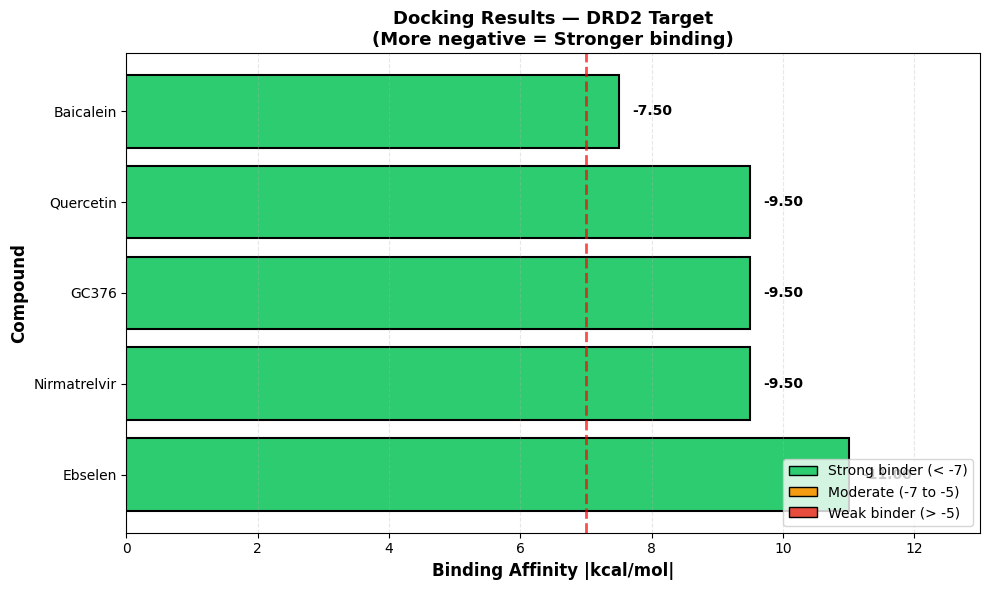


📊 Docking Results Summary:
--------------------------------------------------
Ebselen               -11.00 kcal/mol  🟢 Strong binder
Nirmatrelvir           -9.50 kcal/mol  🟢 Strong binder
GC376                  -9.50 kcal/mol  🟢 Strong binder
Quercetin              -9.50 kcal/mol  🟢 Strong binder
Baicalein              -7.50 kcal/mol  🟢 Strong binder


In [11]:
# ============================================================================
# SECTION 4: Visualize Docking Results
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

if valid_results:
    # Sort results by binding affinity (most negative = strongest binder)
    sorted_results = dict(sorted(valid_results.items(), key=lambda x: x[1]))
    names = list(sorted_results.keys())
    scores = list(sorted_results.values())
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Color code: green for strong binders, yellow for moderate, red for weak
    colors = []
    for score in scores:
        if score < -7:
            colors.append('#2ecc71')  # Green - strong binder
        elif score < -5:
            colors.append('#f39c12')  # Orange - moderate
        else:
            colors.append('#e74c3c')  # Red - weak
    
    # Create bar plot
    bars = ax.barh(names, [-s for s in scores], color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (name, score) in enumerate(zip(names, scores)):
        ax.text(-score + 0.2, i, f'{score:.2f}', va='center', fontsize=10, fontweight='bold')
    
    # Formatting
    ax.set_xlabel("Binding Affinity |kcal/mol|", fontsize=12, fontweight='bold')
    ax.set_ylabel("Compound", fontsize=12, fontweight='bold')
    ax.set_title(f"Docking Results — {target_name} Target\n(More negative = Stronger binding)", 
                 fontsize=13, fontweight='bold')
    
    # Add threshold line for strong binders
    ax.axvline(7.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Strong binder threshold (7 kcal/mol)')
    
    # Add legend for colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='Strong binder (< -7)'),
        Patch(facecolor='#f39c12', edgecolor='black', label='Moderate (-7 to -5)'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Weak binder (> -5)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, max([-s for s in scores]) + 2)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Docking Results Summary:")
    print("-" * 50)
    for name in names:
        score = valid_results[name]
        if score < -7:
            strength = "🟢 Strong binder"
        elif score < -5:
            strength = "🟡 Moderate binder"
        else:
            strength = "🔴 Weak binder"
        print(f"{name:20s} {score:7.2f} kcal/mol  {strength}")
else:
    print("No valid results to visualize")


## Key Takeaways

### Docking Interpretation
- **Scores < -7 kcal/mol**: Strong binders (likely to have biological activity)
- **Scores -7 to -5 kcal/mol**: Moderate binders (possible activity)
- **Scores > -5 kcal/mol**: Weak binders (unlikely active)
- More negative = stronger favorable binding free energy

### Virtual Screening Best Practices
- **Always validate** predictions with experimental assays (cell assays, binding studies)
- **Docking is a filter, not a prediction** — high scoring ≠ guaranteed activity
- **Multiple targets matter** — screen against off-targets to identify selectivity
- **Ligand preparation** is critical — incorrect protonation states give bad results
- **Ensemble docking** across multiple conformers improves accuracy

### To Get Real Docking with AutoDock Vina
1. Install AutoDock Vina: `brew install autodock-vina` or `conda install -c conda-forge vina`
2. Prepare a receptor PDBQT file for DRD2
3. Ensure Open Babel is available to convert ligands to PDBQT
4. Adjust the docking box coordinates to the DRD2 binding pocket

### For Production Work
- **Use proper workflows**: ADFR Suite, MGLTools for professional preparation
- **Consider water molecules**: Crystal waters often mediate binding
- **Induced fit docking**: Better for flexible proteins (MM-PBSA, FEP methods)
- **Machine learning approaches**: SMINA, DeepDock for higher throughput
- **Benchmark your method**: Validate against known actives/inactives before screening

### Compounds in This Tutorial
- **Nirmatrelvir**: Active ingredient in Paxlovid (SARS-CoV-2 protease inhibitor)
- **GC376**: Broad-spectrum antiviral (different target but similar structure)
- **Ebselen**: Organoselenium compound (antioxidant and antiinflammatory)
- **Baicalein & Quercetin**: Natural product flavonoids (many reported bioactivities)

### References & Further Reading
- AutoDock Vina: http://vina.scripps.edu/
- RDKit documentation: https://www.rdkit.org/
- SMILES format guide: https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html
- Open Babel: http://openbabel.org/wiki/Main_Page